## 📊 Lesson 2: Data Interpretation (Distributions & Relationships)

Data interpretaion answers quesstions like
- What does a typical onservation look like?(Mean, median)
- How spread out is the data? (Variance, Standard deviation)
- Are two features related? (Covariance, Correlation)

### Mathematically:

* **Mean** (expectation estimate):
  $$
  \bar{x} = \frac{1}{n} \sum_{i=1}^n x_i
  $$
* **Variance** (spread):
  $$
  s^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2
  $$
* **Covariance** between X and Y:
  $$
  \text{Cov}(X,Y) = \frac{1}{n-1}\sum (x_i - \bar{x})(y_i - \bar{y})
  $$
* **Correlation** (normalized covariance):
  $$
  r = \frac{\text{Cov}(X,Y)}{s_X s_Y}
  $$
  This is what you computed with `.corr()`.

These stats are just functions on vectors (columns of your data matrix). Linear algebra + stats all the way down.

### Why this matters in real data science / AI

Beofore choosing or training any model, you wanr ro know:
- Are features redundant(highly correlated)?
- Are there skewed distribution (may need log transform)?
- Are there clear linear/nonlinear relationship?

This help you
- Engineer better feature,
- Choose appropriate models(linear vs nonlinear),
- interpret models output more confidently.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 50
study_hours = np.random.normal(loc=3, scale=1, size=n).clip(0.5, 6)
sleep_hours = np.random.normal(loc=7, scale=1, size=n).clip(4, 10)

# score depends on study_hours + some noise
score = 50 + 8 * study_hours + np.random.normal(0, 5, size=n)

# add a bot of missingness and a outlier
score[3] = np.nan
study_hours[10] = 20 # obvious outlier

df = pd.DataFrame({
    "StudyHours": study_hours,
    "SleepHours": sleep_hours,
    "Score": score
})

print("Raw data head:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())

Raw data head:
    StudyHours  SleepHours      Score
0    3.496714    7.324084  70.896860
1    2.861736    6.614918  70.790659
2    3.647689    6.323078  77.467936
3    4.523030    7.611676        NaN
4    2.765847    8.031000  71.320344

Missing values:
 StudyHours    0
SleepHours    0
Score         1
dtype: int64


### Clean the Data

In [28]:
df_fitted = df
df_fitted["Score"] = df_fitted["Score"].fillna(df_fitted["Score"].median())

# Detecting outlier
print(df_fitted.describe())
z_score = np.abs((df_fitted - df_fitted.mean())/df_fitted.std())
print("Outliers\n", df_fitted[(z_score > 3).any(axis=1)])

df_fitted.loc[z_score["StudyHours"] > 3, "StudyHours"] = df_fitted["StudyHours"].median()
df_fitted.loc[z_score["SleepHours"] > 3, "SleepHours"] = df_fitted["SleepHours"].median()
df_fitted.loc[z_score["Score"] > 3, "Score"] = df_fitted["Score"].median()

print(df_fitted.describe())

       StudyHours  SleepHours      Score
count   50.000000   50.000000  50.000000
mean     3.123794    7.017781  71.776513
std      2.607979    0.874325   8.360596
min      1.040330    4.380255  55.592759
25%      2.139021    6.503889  67.493286
50%      2.770043    7.046080  71.009969
75%      3.367678    7.587074  75.951102
max     20.000000    8.564644  96.064632
Outliers
     StudyHours  SleepHours      Score
10   20.000000    6.520826  60.698802
24    2.455617    4.380255  72.579224
       StudyHours  SleepHours      Score
count   50.000000   50.000000  50.000000
mean     2.779195    7.071097  71.776513
std      0.933038    0.787140   8.360596
min      1.040330    5.012431  55.592759
25%      2.139021    6.542592  67.493286
50%      2.767953    7.066564  71.009969
75%      3.336276    7.587074  75.951102
max      4.852278    8.564644  96.064632


### Univariate Interpretation (Distrobutions)

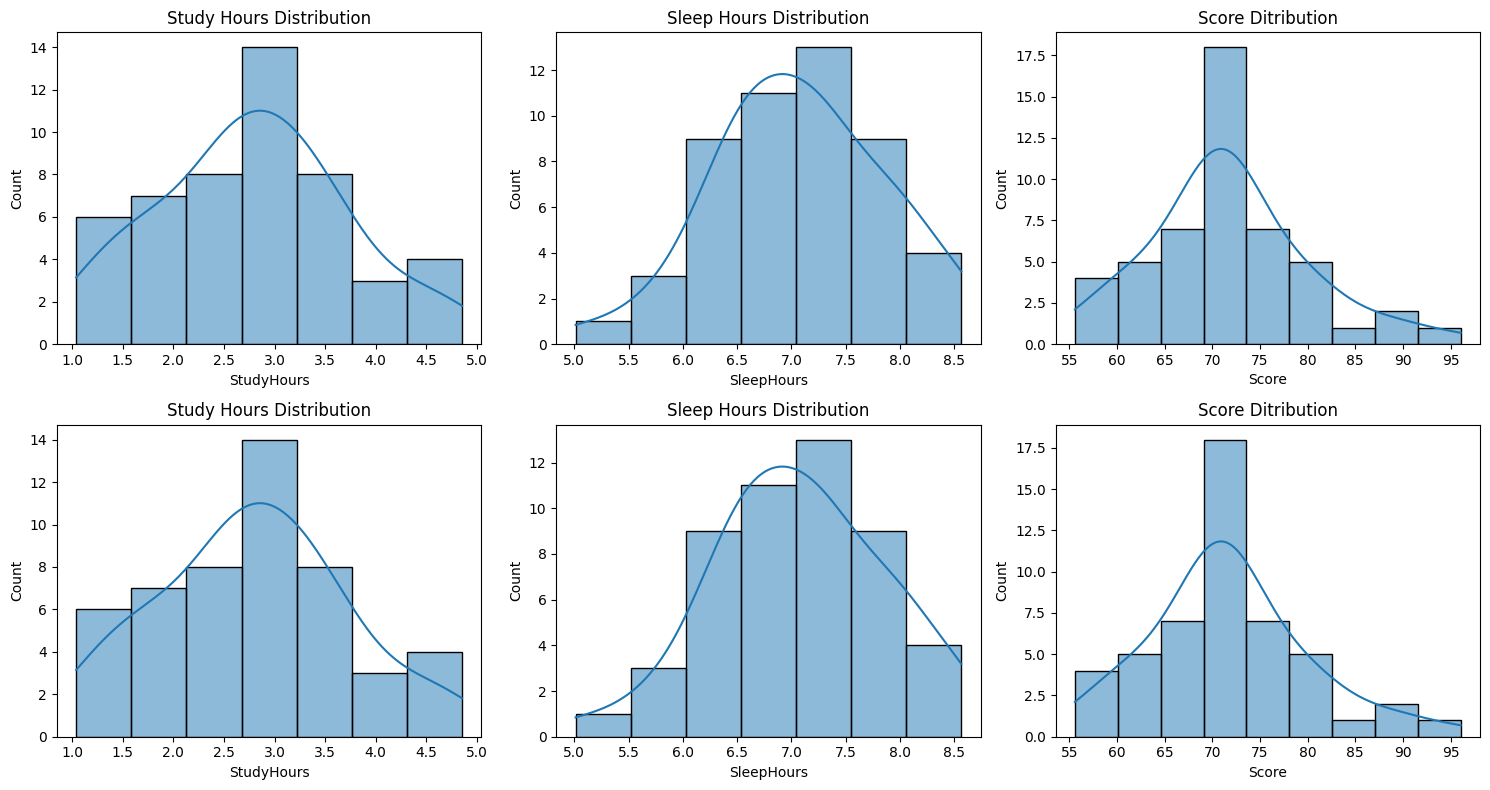

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.histplot(df["StudyHours"], kde=True, ax= axes[0][0])
axes[0][0].set_title("Study Hours Distribution")

sns.histplot(df["SleepHours"], kde=True, ax=axes[0][1])
axes[0][1].set_title("Sleep Hours Distribution")

sns.histplot(df["Score"], kde=True, ax=axes[0][2])
axes[0][2].set_title("Score Ditribution")

sns.histplot(df_fitted["StudyHours"], kde=True, ax= axes[1][0])
axes[1][0].set_title("Study Hours Distribution")

sns.histplot(df_fitted["SleepHours"], kde=True, ax=axes[1][1])
axes[1][1].set_title("Sleep Hours Distribution")

sns.histplot(df_fitted["Score"], kde=True, ax=axes[1][2])
axes[1][2].set_title("Score Ditribution")

plt.tight_layout()
plt.show()

#### Question to ask looking at this
- Are socres roughly symmetric or skewed?
- Are there extreme values?
- Does studyhours look roughly nomal arfter capping outliers?

### Bivariate Interpretation: Relationships


 Correlation Matrix
             StudyHours  SleepHours     Score
StudyHours    1.000000    0.095152  0.759856
SleepHours    0.095152    1.000000 -0.060549
Score         0.759856   -0.060549  1.000000


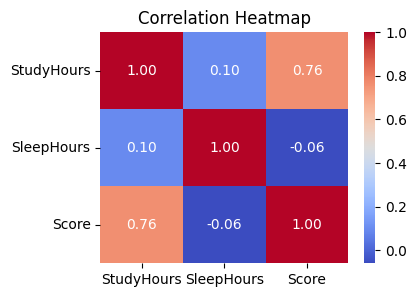

In [30]:
# Correaltion matrix
corr = df.corr(numeric_only=True)
print("\n Correlation Matrix\n", corr)

plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

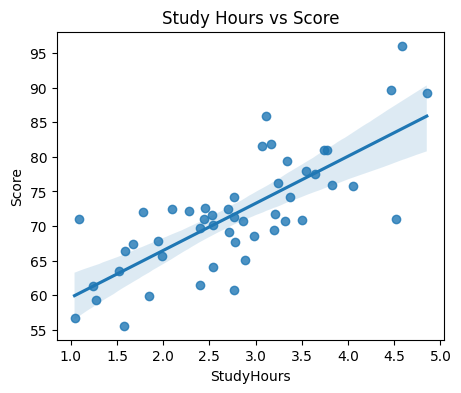

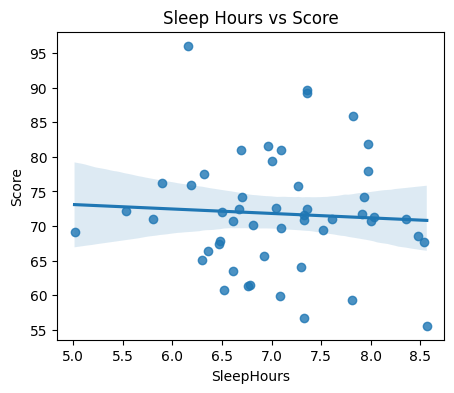

In [31]:
plt.figure(figsize=(5,4))
sns.regplot(data=df, x="StudyHours", y="Score")
plt.title("Study Hours vs Score")
plt.show()

plt.figure(figsize=(5,4))
sns.regplot(data=df, x="SleepHours", y="Score")
plt.title("Sleep Hours vs Score")
plt.show()

#### Now you can interpret
- if corr(StudyHours, Score) is higly positive (say > 0.7), then:

   | As study hours increase, score trend to increase in a fairly linear way.

- If corr(SleepHours, Score) is weaker, then:

   | Sleep might have some effect or none, may be there is an optimal range.
   
This is the bridge to machine learning: When we later fit a regression model, it is basically finding a line/ surface that matches these pattern as well as possible.

### Excercise

In [40]:
import pandas as pd
import numpy as np
data = {
    "TimeOnApp": [5, 10, 3, 8, 15, 2, 20, 7],
    "Purchases": [1, 2, 0, 1, 3, 0, 4, 1],
    "Age":       [22, 25, 19, 30, 35, 18, 40, 27]
}

df = pd.DataFrame(data)
print(df)

   TimeOnApp  Purchases  Age
0          5          1   22
1         10          2   25
2          3          0   19
3          8          1   30
4         15          3   35
5          2          0   18
6         20          4   40
7          7          1   27


       TimeOnApp  Purchases        Age
count   8.000000   8.000000   8.000000
mean    8.750000   1.500000  27.000000
std     6.135378   1.414214   7.708993
min     2.000000   0.000000  18.000000
25%     4.500000   0.750000  21.250000
50%     7.500000   1.000000  26.000000
75%    11.250000   2.250000  31.250000
max    20.000000   4.000000  40.000000

Missing values
 TimeOnApp    0
Purchases    0
Age          0
dtype: int64
   TimeOnApp  Purchases       Age
0   0.611209   0.353553  0.648593
1   0.203736   0.353553  0.259437
2   0.937188   1.060660  1.037749
3   0.122242   0.353553  0.389156
4   1.018682   1.060660  1.037749
5   1.100177   1.060660  1.167468
6   1.833628   1.767767  1.686342
7   0.285231   0.353553  0.000000

 Outliers
 Empty DataFrame
Columns: [TimeOnApp, Purchases, Age]
Index: []


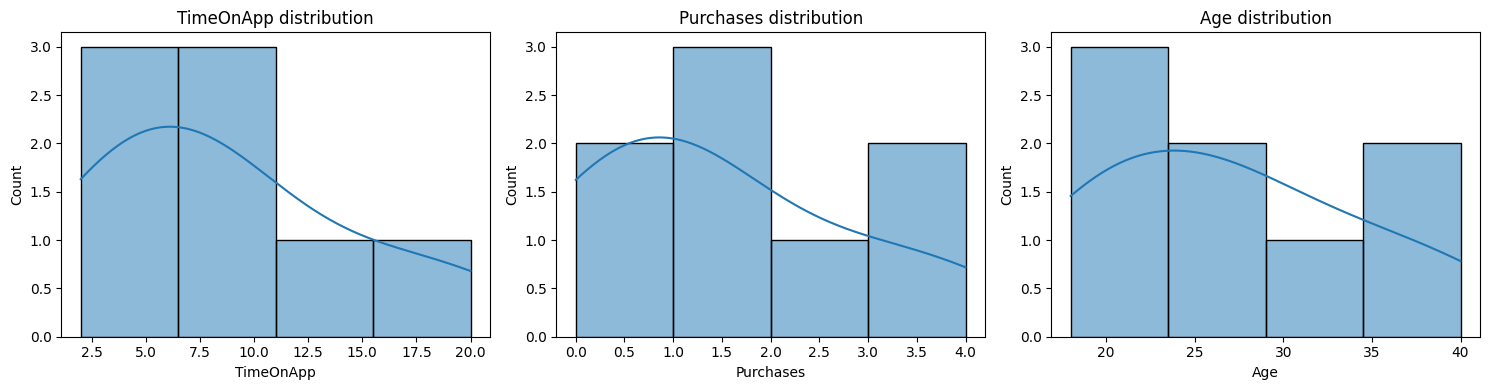


Correlation
            TimeOnApp  Purchases       Age
TimeOnApp   1.000000   0.987863  0.957464
Purchases   0.987863   1.000000  0.917249
Age         0.957464   0.917249  1.000000


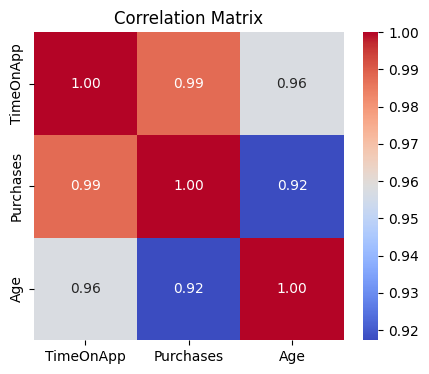

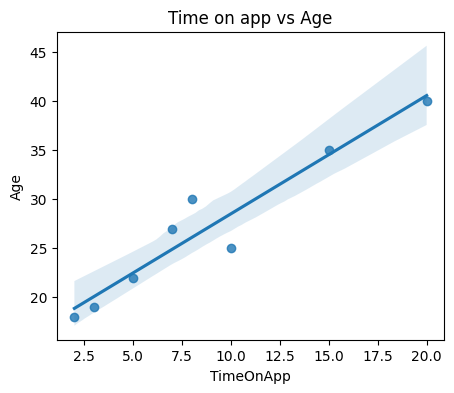

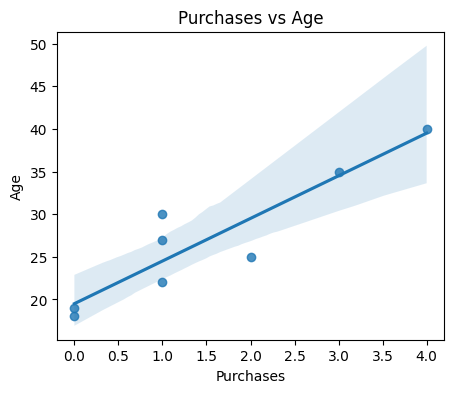

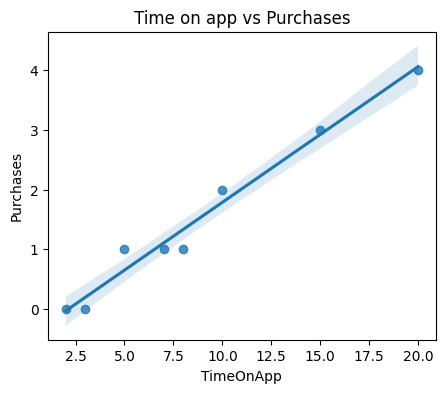

In [ ]:
print(df.describe())

print("\nMissing values\n", df.isna().sum())

z_score = np.abs((df - df.mean()) / df.std())
print(z_score)
print("\n Outliers\n", df[(z_score > 2.5).any(axis=1)])

# Univariate Distribution
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.histplot(df["TimeOnApp"], kde=True, ax=axes[0])
axes[0].set_title("TimeOnApp distribution")

sns.histplot(df["Purchases"], kde=True, ax=axes[1])
axes[1].set_title("Purchases distribution")

sns.histplot(df["Age"], kde=True, ax=axes[2])
axes[2].set_title("Age distribution")

plt.tight_layout()
plt.show()

corr = df.corr(numeric_only=True)
print("\nCorrelation\n", corr)

# Bivariate Distribution
plt.figure(figsize=(5,4))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Regression
plt.figure(figsize=(5,4))

sns.regplot(data=df, x=df["TimeOnApp"], y=df["Age"])
plt.title("Time on app vs Age")
plt.show()

plt.figure(figsize=(5,4))
sns.regplot(data=df, x=df["Purchases"], y=df["Age"])
plt.title("Purchases vs Age")
plt.show()

plt.figure(figsize=(5,4))

sns.regplot(data=df, x=df["TimeOnApp"], y=df["Purchases"])
plt.title("Time on app vs Purchases")
plt.show()

# Interpretations

# Does spending more time on the app seem associated with more purchases?
# Interpretation: Yes, corr value 0.99 suggest that time on the app is strongly related with more purchase.

# Does age seem strongly related to purchases here?
# Interpretation: Yes age seem strongly related to purchase as corr value is 0.92